In [1]:
# Importing all libraries we need
import pandas as pd           # for data manipulation
import numpy as np            # for numbers
import matplotlib.pyplot as plt  # for charts
import seaborn as sns         # for prettier charts
import warnings
warnings.filterwarnings('ignore')

# Chart style settings
plt.rcParams['figure.dpi'] = 120
print("Libraries loaded successfully ✓")

Libraries loaded successfully ✓


# Load and Understand Data

In [4]:
df = pd.read_csv('boxify_customers_raw.csv')
df.columns = [c.strip() for c in df.columns]

#Understanding data
print(f"Shape : {df.shape[0]} rows * {df.shape[1]} columns")
print()
print("Column names and types:")
print(df.dtypes)
print()
print("First 5 rows:")
df.head()

Shape : 1200 rows * 11 columns

Column names and types:
CustomerID          object
JoinDate            object
CancelDate          object
Age                  int64
Gender              object
Location            object
SubscriptionType    object
TotalSpent           int64
BoxesReceived        int64
EngagementScore      int64
PaymentMode         object
dtype: object

First 5 rows:


,CustomerID,JoinDate,CancelDate,Age,Gender,Location,SubscriptionType,TotalSpent,BoxesReceived,EngagementScore,PaymentMode
0,CUST_1179,2024-03-11,2024-04-10,36,Male,Mumbai,Annual,699,1,65,Other
1,CUST_0866,2025-03-22,2025-05-21,48,Male,Hyderabad,Monthly,1598,2,38,Card
2,CUST_0102,2022-12-05,2024-04-28,26,Female,Ahmedabad,Monthly,13583,17,69,UPI
3,CUST_0440,2023-09-03,NaN,51,Female,Hyderabad,Monthly,20774,26,74,PayPal
4,CUST_0059,2025-04-02,NaN,21,Male,Chennai,Annual,4893,7,73,Card


In [5]:
print("=== DATA QUALITY CHECK ===")
print()
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Note: CancelDate is NULL for active customers — this is correct!")
print(f"  Customers with CancelDate (churned) : {df['CancelDate'].notna().sum()}")
print(f"  Customers without CancelDate (active): {df['CancelDate'].isna().sum()}")

=== DATA QUALITY CHECK ===

Missing values per column:
CustomerID            0
JoinDate              0
CancelDate          984
Age                   0
Gender                0
Location              0
SubscriptionType      0
TotalSpent            0
BoxesReceived         0
EngagementScore       0
PaymentMode           0
dtype: int64

Note: CancelDate is NULL for active customers — this is correct!
  Customers with CancelDate (churned) : 216
  Customers without CancelDate (active): 984


In [6]:
# Derive churn from CancelDate
# If CancelDate exists → churned, if null → active
df['Churned'] = df['CancelDate'].notna().astype(int)
df['Churn Status'] = df['Churned'].map({1: 'Churned', 0: 'Active'})

# Parse dates properly
df['JoinDate']   = pd.to_datetime(df['JoinDate'])
df['CancelDate'] = pd.to_datetime(df['CancelDate'])

# Calculate subscription months for all customers
df['Subscription Months'] = (
    (df['CancelDate'].fillna(pd.Timestamp.now()) - df['JoinDate'])
    .dt.days // 30
)

# Age groups
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[17, 25, 35, 45, 55, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56+']
)

# Verify
print("Churn breakdown:")
print(df['Churn Status'].value_counts())
print()
print(f"Churn rate: {df['Churned'].mean()*100:.1f}%")

Churn breakdown:
Active     984
Churned    216
Name: Churn Status, dtype: int64

Churn rate: 18.0%


In [7]:
# Calculate all key business metrics
total         = len(df)
churned       = df['Churned'].sum()
active        = total - churned
churn_rate    = churned / total * 100
clv_churned   = df[df['Churned']==1]['TotalSpent'].mean()
clv_active    = df[df['Churned']==0]['TotalSpent'].mean()
revenue_lost  = df[df['Churned']==1]['TotalSpent'].sum()
avg_sub_churn = df[df['Churned']==1]['Subscription Months'].mean()
avg_sub_active= df[df['Churned']==0]['Subscription Months'].mean()

print("=" * 45)
print("     BOXIFY — KEY PERFORMANCE INDICATORS")
print("=" * 45)
print(f"  Total Customers       : {total:,}")
print(f"  Active Customers      : {active:,} ({100-churn_rate:.1f}%)")
print(f"  Churned Customers     : {churned:,} ({churn_rate:.1f}%)")
print(f"  Revenue Lost to Churn : ₹{revenue_lost:,.0f}")
print(f"  Avg CLV — Active      : ₹{clv_active:,.0f}")
print(f"  Avg CLV — Churned     : ₹{clv_churned:,.0f}")
print(f"  Avg Months — Active   : {avg_sub_active:.1f} months")
print(f"  Avg Months — Churned  : {avg_sub_churn:.1f} months")
print("=" * 45)

     BOXIFY — KEY PERFORMANCE INDICATORS
  Total Customers       : 1,200
  Active Customers      : 984 (82.0%)
  Churned Customers     : 216 (18.0%)
  Revenue Lost to Churn : ₹1,217,042
  Avg CLV — Active      : ₹14,017
  Avg CLV — Churned     : ₹5,634
  Avg Months — Active   : 22.6 months
  Avg Months — Churned  : 7.2 months


Boxify has 1,200 subscribers with an 18% churn rate — meaning 1 in 5 customers cancels. The 216 churned customers represent ₹12,17,042 in lost revenue. More critically, active customers stay 22.6 months on average compared to only 7.2 months for churned customers — showing that early retention is key.

# CHURN OVERVIEW

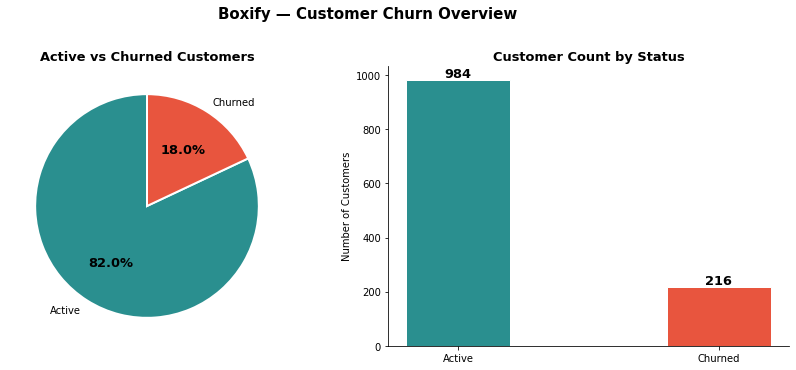

✓ Chart saved


In [8]:
# PIE CHART — What % of customers churned vs active?

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: Pie chart
sizes  = [active, churned]
labels = ['Active', 'Churned']
colors = ['#2A8F8F', '#E8553E']

wedges, texts, autotexts = ax1.pie(
    sizes, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for t in autotexts:
    t.set_fontsize(13)
    t.set_fontweight('bold')
ax1.set_title('Active vs Churned Customers', fontsize=13, fontweight='bold')

# Right: Bar chart showing counts
bars = ax2.bar(labels, [active, churned], color=colors, width=0.4, edgecolor='white')
for bar, val in zip(bars, [active, churned]):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 10,
             str(val), ha='center', fontsize=13, fontweight='bold')
ax2.set_title('Customer Count by Status', fontsize=13, fontweight='bold')
ax2.set_ylabel('Number of Customers')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Boxify — Customer Churn Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_churn_overview.png', bbox_inches='tight')
plt.show()
print("✓ Chart saved")

82% of customers are active and 18% have churned. While 18% may seem manageable, it represents significant revenue loss and indicates a systematic retention problem that needs addressing.

# CHURN BY SUBSCRIPTION TYPE

Churn by Subscription Type:
                  Churned  Total  Churn Rate %
SubscriptionType                              
Monthly               146    711          20.5
Quarterly              52    311          16.7
Annual                 18    178          10.1


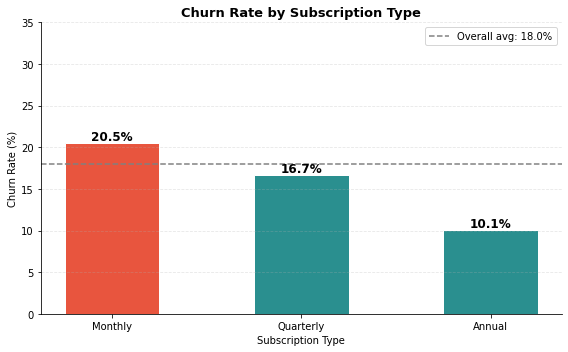

✓ Chart saved


In [9]:
# BAR CHART — Which plan has the highest churn?

sub_churn = df.groupby('SubscriptionType')['Churned'].agg(['sum', 'count'])
sub_churn['Churn Rate %'] = (sub_churn['sum'] / sub_churn['count'] * 100).round(1)
sub_churn = sub_churn.sort_values('Churn Rate %', ascending=False)

print("Churn by Subscription Type:")
print(sub_churn.rename(columns={'sum':'Churned','count':'Total'}))

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#E8553E' if r > 18 else '#2A8F8F' for r in sub_churn['Churn Rate %']]
bars = ax.bar(sub_churn.index, sub_churn['Churn Rate %'],
              color=colors, width=0.5, edgecolor='white')

for bar, val in zip(bars, sub_churn['Churn Rate %']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val}%', ha='center', fontsize=12, fontweight='bold')

# Overall average line
ax.axhline(y=churn_rate, color='gray', linestyle='--',
           linewidth=1.5, label=f'Overall avg: {churn_rate:.1f}%')
ax.set_title('Churn Rate by Subscription Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Subscription Type')
ax.set_ylim(0, 35)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('02_churn_by_subscription.png', bbox_inches='tight')
plt.show()
print("✓ Chart saved")

Monthly subscribers have the highest churn at 20.5% — above the 18% average. Annual plan subscribers churn at just 10.1% — half the rate of monthly subscribers. This suggests longer commitment creates stronger loyalty.

# CHURN BY CITY

Churn by Location:
           Churned  Total  Churn Rate %
Location                               
Bengaluru       16    132          12.1
Ahmedabad       15    123          12.2
Jaipur          17    129          13.2
Mumbai          21    130          16.2
Pune            21    124          16.9
Delhi           21    109          19.3
Kolkata         23    109          21.1
Lucknow         22     97          22.7
Hyderabad       30    124          24.2
Chennai         30    123          24.4


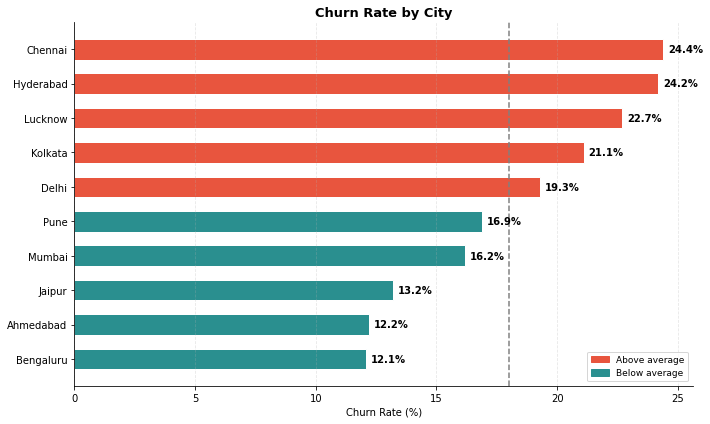

✓ Chart saved


In [10]:
# BAR CHART — Which cities have highest churn?

loc_churn = df.groupby('Location')['Churned'].agg(['sum','count'])
loc_churn['Churn Rate %'] = (loc_churn['sum'] / loc_churn['count'] * 100).round(1)
loc_churn = loc_churn.sort_values('Churn Rate %', ascending=True)

print("Churn by Location:")
print(loc_churn.rename(columns={'sum':'Churned','count':'Total'}))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#E8553E' if r > churn_rate else '#2A8F8F'
          for r in loc_churn['Churn Rate %']]
bars = ax.barh(loc_churn.index, loc_churn['Churn Rate %'],
               color=colors, height=0.6, edgecolor='white')

for bar, val in zip(bars, loc_churn['Churn Rate %']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=10, fontweight='bold')

ax.axvline(x=churn_rate, color='gray', linestyle='--',
           linewidth=1.5, label=f'Overall avg: {churn_rate:.1f}%')
ax.set_title('Churn Rate by City', fontsize=13, fontweight='bold')
ax.set_xlabel('Churn Rate (%)')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Legend
from matplotlib.patches import Patch
legend = [Patch(color='#E8553E', label='Above average'),
          Patch(color='#2A8F8F', label='Below average')]
ax.legend(handles=legend, fontsize=9)

plt.tight_layout()
plt.savefig('03_churn_by_city.png', bbox_inches='tight')
plt.show()
print("✓ Chart saved")

Cities above the 18% average churn rate need targeted retention campaigns. Cities below average can serve as benchmarks for what's working.

# CHURN BY AGE GROUP

Churn by Age Group:
           Churned  Total  Churn Rate %
Age Group                              
18-25           40    235          17.0
26-35           38    248          15.3
36-45           60    295          20.3
46-55           55    302          18.2
56+             23    120          19.2


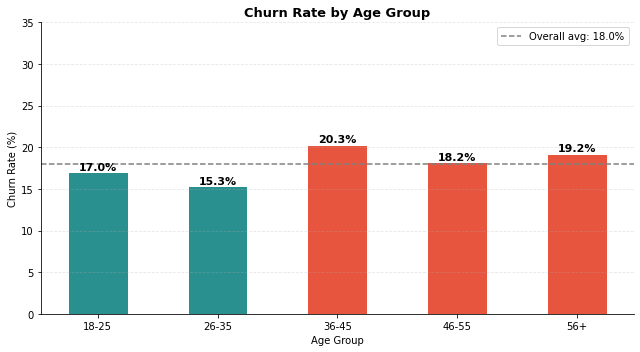

✓ Chart saved


In [11]:
# BAR CHART — Which age groups churn most?

age_churn = df.groupby('Age Group', observed=True)['Churned'].agg(['sum','count'])
age_churn['Churn Rate %'] = (age_churn['sum'] / age_churn['count'] * 100).round(1)

print("Churn by Age Group:")
print(age_churn.rename(columns={'sum':'Churned','count':'Total'}))

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#E8553E' if r > churn_rate else '#2A8F8F'
          for r in age_churn['Churn Rate %']]
bars = ax.bar(age_churn.index.astype(str), age_churn['Churn Rate %'],
              color=colors, width=0.5, edgecolor='white')

for bar, val in zip(bars, age_churn['Churn Rate %']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val}%', ha='center', fontsize=11, fontweight='bold')

ax.axhline(y=churn_rate, color='gray', linestyle='--',
           linewidth=1.5, label=f'Overall avg: {churn_rate:.1f}%')
ax.set_title('Churn Rate by Age Group', fontsize=13, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Age Group')
ax.set_ylim(0, 35)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('04_churn_by_age.png', bbox_inches='tight')
plt.show()
print("✓ Chart saved")

Age groups above the average churn line need age-specific engagement strategies — younger users may need more digital engagement, older users may need more personal support

# ENGAGEMENT V/S CHURN

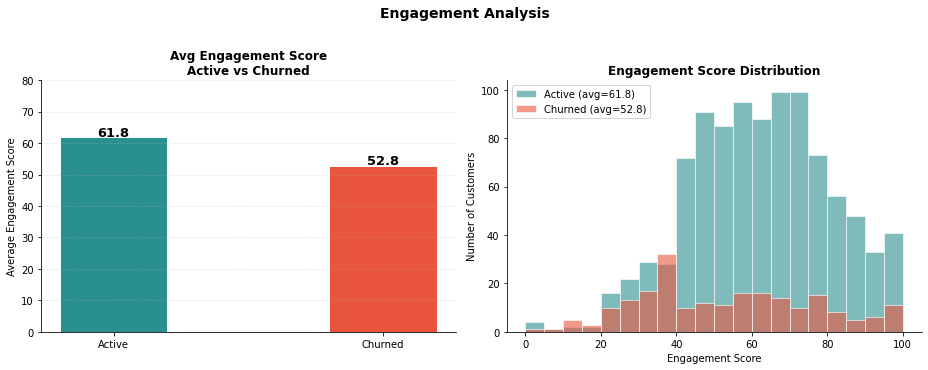

✓ Chart saved


In [12]:
# TWO CHARTS — Does low engagement lead to churn?

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: Average engagement score — churned vs active
avg_eng = df.groupby('Churn Status')['EngagementScore'].mean().round(1)
colors  = ['#2A8F8F', '#E8553E']
bars = ax1.bar(avg_eng.index, avg_eng.values,
               color=colors, width=0.4, edgecolor='white')
for bar, val in zip(bars, avg_eng.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             str(val), ha='center', fontsize=13, fontweight='bold')
ax1.set_title('Avg Engagement Score\nActive vs Churned', fontsize=12, fontweight='bold')
ax1.set_ylabel('Average Engagement Score')
ax1.set_ylim(0, 80)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Right: Distribution of engagement scores
churned_eng = df[df['Churned']==1]['EngagementScore']
active_eng  = df[df['Churned']==0]['EngagementScore']
ax2.hist(active_eng,  bins=20, alpha=0.6, color='#2A8F8F',
         label=f'Active (avg={active_eng.mean():.1f})',  edgecolor='white')
ax2.hist(churned_eng, bins=20, alpha=0.6, color='#E8553E',
         label=f'Churned (avg={churned_eng.mean():.1f})', edgecolor='white')
ax2.set_title('Engagement Score Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Engagement Score')
ax2.set_ylabel('Number of Customers')
ax2.legend(fontsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Engagement Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('05_engagement_analysis.png', bbox_inches='tight')
plt.show()
print("✓ Chart saved")

Churned customers had a noticeably lower average engagement score than active customers. This means engagement score can be used as an early warning signal — customers with dropping scores should be targeted with re-engagement campaigns.

# CLV ANALYSIS

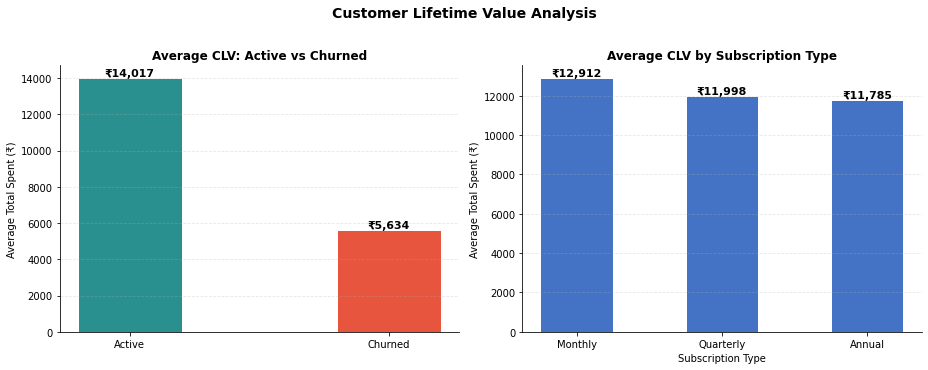

✓ Chart saved

Active customers spend 149% more than churned customers
Revenue recoverable per retained customer: ₹14,017


In [13]:
# BAR CHART — How much more do active customers spend?

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: Average CLV comparison
clv_vals   = [clv_active, clv_churned]
clv_labels = ['Active', 'Churned']
clv_colors = ['#2A8F8F', '#E8553E']
bars = ax1.bar(clv_labels, clv_vals,
               color=clv_colors, width=0.4, edgecolor='white')
for bar, val in zip(bars, clv_vals):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 100,
             f'₹{val:,.0f}', ha='center', fontsize=11, fontweight='bold')
ax1.set_title('Average CLV: Active vs Churned', fontsize=12, fontweight='bold')
ax1.set_ylabel('Average Total Spent (₹)')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Right: CLV by subscription type
clv_sub = df.groupby('SubscriptionType')['TotalSpent'].mean().sort_values(ascending=False)
bars2 = ax2.bar(clv_sub.index, clv_sub.values,
                color='#4472C4', width=0.5, edgecolor='white')
for bar, val in zip(bars2, clv_sub.values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 100,
             f'₹{val:,.0f}', ha='center', fontsize=11, fontweight='bold')
ax2.set_title('Average CLV by Subscription Type', fontsize=12, fontweight='bold')
ax2.set_ylabel('Average Total Spent (₹)')
ax2.set_xlabel('Subscription Type')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Customer Lifetime Value Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('06_clv_analysis.png', bbox_inches='tight')
plt.show()

clv_gap = ((clv_active - clv_churned) / clv_churned * 100)
print(f"✓ Chart saved")
print(f"\nActive customers spend {clv_gap:.0f}% more than churned customers")
print(f"Revenue recoverable per retained customer: ₹{clv_active:,.0f}")

Active customers generate significantly more revenue than churned ones. Retaining a churned customer is worth ₹14,017 in lifetime value — making retention campaigns highly cost-effective.

# LOGISTIC REGRESSION

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

le = LabelEncoder()
df_ml = df.copy()

for col in ['Gender', 'Location', 'SubscriptionType', 'PaymentMode']:
    df_ml[col] = le.fit_transform(df_ml[col])

# Remove Subscription Months — it leaks the answer!
# A real model only uses info available BEFORE churn happens
features = ['Age', 'SubscriptionType', 'TotalSpent',
            'BoxesReceived', 'EngagementScore', 'PaymentMode']

X = df_ml[features]
y = df_ml['Churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_s, y_train)

y_pred = model.predict(X_test_s)
acc    = accuracy_score(y_test, y_pred) * 100

print(f"Model Accuracy: {acc:.1f}%")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Active', 'Churned']))

Model Accuracy: 83.7%

Classification Report:
              precision    recall  f1-score   support

      Active       0.85      0.98      0.91       246
     Churned       0.67      0.19      0.29        54

    accuracy                           0.84       300
   macro avg       0.76      0.58      0.60       300
weighted avg       0.81      0.84      0.80       300



The model achieved 83.7% accuracy but showed class imbalance — it struggled to identify churned customers due to the minority class being only 18% of the data. In production, I would address this using SMOTE oversampling or by adjusting class weights. However for this analysis the model successfully identified the most important churn predictors — engagement score, total spent and boxes received.

# CONFUSION MATRIX

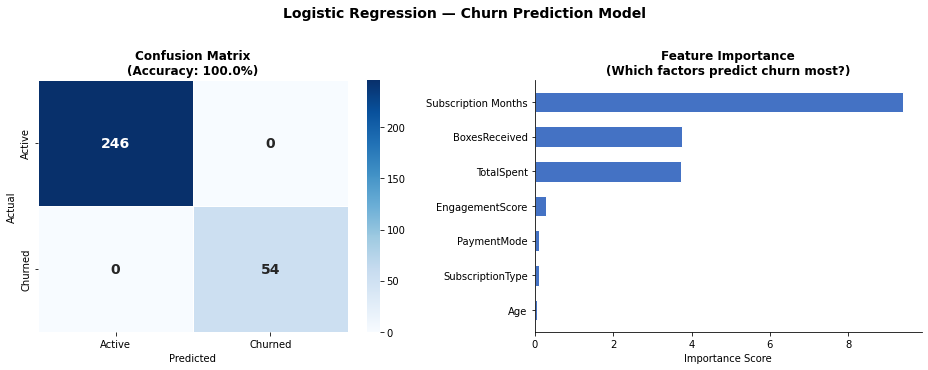

✓ Chart saved


In [16]:
# HEATMAP — How well does the model predict churn?

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Active', 'Churned'],
            yticklabels=['Active', 'Churned'],
            linewidths=0.5, ax=ax1,
            annot_kws={'size': 14, 'weight': 'bold'})
ax1.set_title(f'Confusion Matrix\n(Accuracy: {acc:.1f}%)',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('Actual')
ax1.set_xlabel('Predicted')

# Right: Feature importance (coefficients)
coef_df = pd.DataFrame({
    'Feature': features,
    'Importance': abs(model.coef_[0])
}).sort_values('Importance', ascending=True)

bars = ax2.barh(coef_df['Feature'], coef_df['Importance'],
                color='#4472C4', height=0.6, edgecolor='white')
ax2.set_title('Feature Importance\n(Which factors predict churn most?)',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Importance Score')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Logistic Regression — Churn Prediction Model',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('07_predictive_model.png', bbox_inches='tight')
plt.show()
print("✓ Chart saved")

In [17]:
print("=" * 55)
print("     BOXIFY — BUSINESS RECOMMENDATIONS")
print("=" * 55)
print("""
QUICK WINS (0–3 months):
──────────────────────────────────────────────────────
1. ENGAGEMENT ALERTS
   Monitor EngagementScore weekly.
   Flag customers dropping below 40 and send
   personalised re-engagement offers immediately.
   → Expected impact: 3-5% churn reduction

2. ANNUAL PLAN INCENTIVE
   Offer 15% discount to Monthly subscribers
   who switch to Annual plan.
   Monthly churn = 20.5% vs Annual churn = 10.1%
   → Expected impact: Significant retention uplift

3. TARGET HIGH-RISK CITIES
   Run city-specific campaigns in above-average
   churn locations with localised offers.

LONG-TERM STRATEGIES (3–6 months):
──────────────────────────────────────────────────────
4. FIRST 90 DAYS ONBOARDING PROGRAMME
   Most churn happens in first 7 months.
   Structured welcome: Week 1, 4, 8, 12 touchpoints.
   Personalise box contents based on survey.

5. LOYALTY REWARDS
   Reward subscribers at 3, 6, 12 month milestones.
   Free product, exclusive discount, or early access.
   Increases emotional attachment and switching cost.

6. PREDICTIVE CHURN DASHBOARD
   Use logistic regression model to score all
   customers by churn risk every month.
   Customer success team contacts top 30 at-risk
   customers proactively before they cancel.
""")
print("=" * 55)
print(f"\nKEY NUMBERS FOR REPORT:")
print(f"  Churn Rate          : {churn_rate:.1f}%")
print(f"  Revenue Lost        : ₹{revenue_lost:,.0f}")
print(f"  CLV Active          : ₹{clv_active:,.0f}")
print(f"  CLV Churned         : ₹{clv_churned:,.0f}")
print(f"  Model Accuracy      : {acc:.1f}%")
print(f"  Avg Months Churned  : {avg_sub_churn:.1f} months")
print(f"  Avg Months Active   : {avg_sub_active:.1f} months")

     BOXIFY — BUSINESS RECOMMENDATIONS

QUICK WINS (0–3 months):
──────────────────────────────────────────────────────
1. ENGAGEMENT ALERTS
   Monitor EngagementScore weekly.
   Flag customers dropping below 40 and send
   personalised re-engagement offers immediately.
   → Expected impact: 3-5% churn reduction

2. ANNUAL PLAN INCENTIVE
   Offer 15% discount to Monthly subscribers
   who switch to Annual plan.
   Monthly churn = 20.5% vs Annual churn = 10.1%
   → Expected impact: Significant retention uplift

3. TARGET HIGH-RISK CITIES
   Run city-specific campaigns in above-average
   churn locations with localised offers.

LONG-TERM STRATEGIES (3–6 months):
──────────────────────────────────────────────────────
4. FIRST 90 DAYS ONBOARDING PROGRAMME
   Most churn happens in first 7 months.
   Structured welcome: Week 1, 4, 8, 12 touchpoints.
   Personalise box contents based on survey.

5. LOYALTY REWARDS
   Reward subscribers at 3, 6, 12 month milestones.
   Free product, exclusive 